# GLIMMER v3: The Actual Method, Not an Approximation of It

Notebook 03 (v1) tested the paper's idea using one fixed weight pair, the population
average from their Table 3, applied to every patient. This notebook does what the paper
actually does: search for each patient's own best weight pair with a genetic algorithm,
and also add the second architecture (CNN-Transformer) to check the loss idea isn't
tied to one specific model.

**Why this might fix v1's problem:** notebook 03 found the fixed average weights helped
the hypo/hyper regions but overcorrected badly for the normal region, on some people
worse than others. A quick single-patient test of the search below found weights of
about (1.0, 1.3) for that person, far gentler than the population average of (3.29,
2.38). If different people genuinely need very different amounts of correction, forcing
everyone to use the population average could be exactly why v1 came out worse overall
instead of better.

**Scope note:** the genetic algorithm here is deliberately smaller than the paper's own
(population 6, 6 generations, instead of 20 and 25), for the reasons and math laid out in
`azt1d/glimmer/ga.py`. It's a real search, not a fixed shortcut, just a cheaper one.

**Status: everything below is written and function-tested at small scale (see the
conversation), but the full-scale runs have not been executed.** Time estimates, measured
on real data:
- Transformer v0 + v1 across 25 subjects: roughly 20-30 minutes (12x more parameters
  than CNN-LSTM, so slower per model).
- The GA search across 25 subjects: roughly 60-65 minutes, measured directly from one
  patient's run (21 evaluations, ~7.2 sec each) and scaled up.
- Final CNN-LSTM retraining with each patient's found weights: a few minutes, same cost
  as v0/v1's own runs.

Total: **roughly 1.5 hours of compute**, most of it the GA search.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting, synthetic
from azt1d import reference as ref
from azt1d.glimmer.train import run_with_checkpoints, train_prepared_model, prepare_subject_data, region_errors
from azt1d.glimmer.ga import search_patient_weights
from azt1d.glimmer import checkpoint

plotting.apply_style()
pd.set_option("display.max_columns", None)


## 1. Load data


In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SYNTHETIC_DIR = PROCESSED_DIR / "synthetic"

has_real_data = loading.find_dataset_zip(RAW_DIR) is not None or bool(loading.discover_subject_files(RAW_DIR))

if has_real_data:
    print("Found real AZT1D data in data/raw/ -- loading it.")
    df = loading.load_real_dataset(RAW_DIR, PROCESSED_DIR)
    USING_SYNTHETIC = False
else:
    print("No real dataset found in data/raw/ yet -- using synthetic placeholder data.")
    if not any(SYNTHETIC_DIR.glob("*.csv")):
        synthetic.write_synthetic_csvs(SYNTHETIC_DIR)
    df = loading.load_all_subjects(SYNTHETIC_DIR)
    USING_SYNTHETIC = True

print(f"Loaded {len(df):,} rows across {df['subject_id'].nunique()} subjects.")

CHECKPOINT_DIR = PROCESSED_DIR / "checkpoints"


Found real AZT1D data in data/raw/ -- loading it.


Loaded 300,923 rows across 25 subjects.


## 2. Second architecture: does the idea hold up on a Transformer too?

The paper's whole point is that the weighted-loss training strategy is architecture-
agnostic, it should help regardless of what model it's applied to. Same v0/v1 comparison
as notebook 03, just swapping the backbone. Checkpointed like everything else in this
notebook, safe to interrupt and rerun.


In [3]:
GLIMMER_WEIGHTS = ref.GLIMMER_PAPER_WEIGHTS["cnn_lstm"]

summary_tf_v0, results_tf_v0 = run_with_checkpoints(
    df, CHECKPOINT_DIR / "cnn_transformer_v0", epochs=30, architecture="cnn_transformer", region_weights=None)
summary_tf_v1, results_tf_v1 = run_with_checkpoints(
    df, CHECKPOINT_DIR / "cnn_transformer_v1", epochs=30, architecture="cnn_transformer", region_weights=GLIMMER_WEIGHTS)

print(f"Transformer v0: RMSE {summary_tf_v0['rmse'].mean():.2f} +/- {summary_tf_v0['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_tf_v0['mae'].mean():.2f} +/- {summary_tf_v0['mae'].std():.2f} mg/dL")
print(f"Transformer v1: RMSE {summary_tf_v1['rmse'].mean():.2f} +/- {summary_tf_v1['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_tf_v1['mae'].mean():.2f} +/- {summary_tf_v1['mae'].std():.2f} mg/dL")
print()
print("Paper's Transformer baseline on AZT1D: RMSE 25.39 +/- 5.21 mg/dL, MAE 18.50 +/- 4.03 mg/dL")
print("Paper's GLIMMER(Transformer) on AZT1D: RMSE 22.48 +/- 3.57 mg/dL is CNN-LSTM's number -- paper doesn't")
print("break out a separate Transformer+GLIMMER number for AZT1D in the excerpt we have; treat this as a")
print("directional check (did the weighted loss move things the same way as it did for CNN-LSTM) rather than")
print("an exact target to hit.")


Subject 1: loaded from checkpoint (RMSE=25.64 mg/dL)
Subject 2: loaded from checkpoint (RMSE=35.36 mg/dL)
Subject 3: loaded from checkpoint (RMSE=25.15 mg/dL)
Subject 4: loaded from checkpoint (RMSE=34.97 mg/dL)
Subject 5: loaded from checkpoint (RMSE=29.04 mg/dL)
Subject 6: loaded from checkpoint (RMSE=25.35 mg/dL)
Subject 7: loaded from checkpoint (RMSE=30.63 mg/dL)
Subject 8: loaded from checkpoint (RMSE=35.98 mg/dL)
Subject 9: loaded from checkpoint (RMSE=33.29 mg/dL)
Subject 10: loaded from checkpoint (RMSE=33.16 mg/dL)
Subject 11: loaded from checkpoint (RMSE=34.93 mg/dL)
Subject 12: loaded from checkpoint (RMSE=28.38 mg/dL)
Subject 13: loaded from checkpoint (RMSE=22.45 mg/dL)
Subject 14: loaded from checkpoint (RMSE=32.08 mg/dL)
Subject 15: loaded from checkpoint (RMSE=51.56 mg/dL)
Subject 16: loaded from checkpoint (RMSE=27.43 mg/dL)
Subject 17: loaded from checkpoint (RMSE=41.77 mg/dL)
Subject 18: loaded from checkpoint (RMSE=33.55 mg/dL)
Subject 19: loaded from checkpoint (R

## 3. The genetic algorithm: search for each patient's own weights

This is Algorithm 1 from the paper (scoped down, see the intro above and
`azt1d/glimmer/ga.py`), run once per patient. Each patient's search is independent of
everyone else's, exactly like the paper's own per-patient personalization. Checkpointed
per patient (lightweight JSON, just the found weights and search history, not a full
model), so an interruption only costs whichever single patient was mid-search.


In [4]:
GA_CHECKPOINT_DIR = CHECKPOINT_DIR / "ga_cnn_lstm"

ga_results = {}
prepared_data = {}

for sid in sorted(df["subject_id"].unique()):
    df_subject = df[df["subject_id"] == sid].reset_index(drop=True)
    data = prepare_subject_data(df_subject)
    prepared_data[sid] = data

    cached = checkpoint.load_ga_result(GA_CHECKPOINT_DIR, sid)
    if cached is not None:
        ga_results[sid] = cached
        print(f"Subject {sid}: loaded from checkpoint (w_hypo={cached['best_weights']['w_hypo']:.2f}, "
              f"w_hyper={cached['best_weights']['w_hyper']:.2f}), val RMSE {cached['best_fitness']:.2f} mg/dL")
        continue

    result = search_patient_weights(data, architecture="cnn_lstm", seed=0)
    checkpoint.save_ga_result(GA_CHECKPOINT_DIR, sid, result.best_weights, result.best_fitness,
                               result.history, result.n_evaluations)
    ga_results[sid] = {
        "best_weights": result.best_weights, "best_fitness": result.best_fitness,
        "history": result.history, "n_evaluations": result.n_evaluations,
    }
    print(f"Subject {sid}: found (w_hypo={result.best_weights['w_hypo']:.2f}, "
          f"w_hyper={result.best_weights['w_hyper']:.2f}), val RMSE {result.best_fitness:.2f} mg/dL "
          f"({result.n_evaluations} candidates tried)")


Subject 1: found (w_hypo=1.04, w_hyper=1.32), val RMSE 29.91 mg/dL (21 candidates tried)


Subject 2: found (w_hypo=1.00, w_hyper=1.24), val RMSE 33.98 mg/dL (21 candidates tried)


Subject 3: found (w_hypo=1.04, w_hyper=1.32), val RMSE 35.53 mg/dL (21 candidates tried)


Subject 4: found (w_hypo=1.37, w_hyper=1.48), val RMSE 34.50 mg/dL (21 candidates tried)


Subject 5: found (w_hypo=1.71, w_hyper=1.49), val RMSE 32.86 mg/dL (21 candidates tried)


...

Subject 21: found (w_hypo=1.00, w_hyper=1.91), val RMSE 44.18 mg/dL (21 candidates tried)


Subject 22: found (w_hypo=1.37, w_hyper=1.15), val RMSE 34.21 mg/dL (21 candidates tried)


Subject 23: found (w_hypo=1.26, w_hyper=1.07), val RMSE 40.62 mg/dL (21 candidates tried)


Subject 24: found (w_hypo=1.74, w_hyper=1.29), val RMSE 32.58 mg/dL (21 candidates tried)


Subject 25: found (w_hypo=1.00, w_hyper=2.02), val RMSE 38.76 mg/dL (21 candidates tried)


In [5]:
weights_table = pd.DataFrame({
    sid: {"w_hypo": r["best_weights"]["w_hypo"], "w_hyper": r["best_weights"]["w_hyper"], "val_rmse": r["best_fitness"]}
    for sid, r in ga_results.items()
}).T
weights_table.index.name = "subject_id"
print("Per-patient weights found by the search, vs. the paper's own Table 3 spread (1.17-5.69 for w_hypo):")
weights_table.round(2)


Per-patient weights found by the search, vs. the paper's own Table 3 spread (1.17-5.69 for w_hypo):


,w_hypo,w_hyper,val_rmse
subject_id,,,
1,1.04,1.32,29.91
2,1.00,1.24,33.98
3,1.04,1.32,35.53
4,1.37,1.48,34.50
5,1.71,1.49,32.86
6,1.79,1.00,27.99
7,1.56,1.26,37.23
8,1.04,1.32,34.62
9,4.36,6.26,44.72


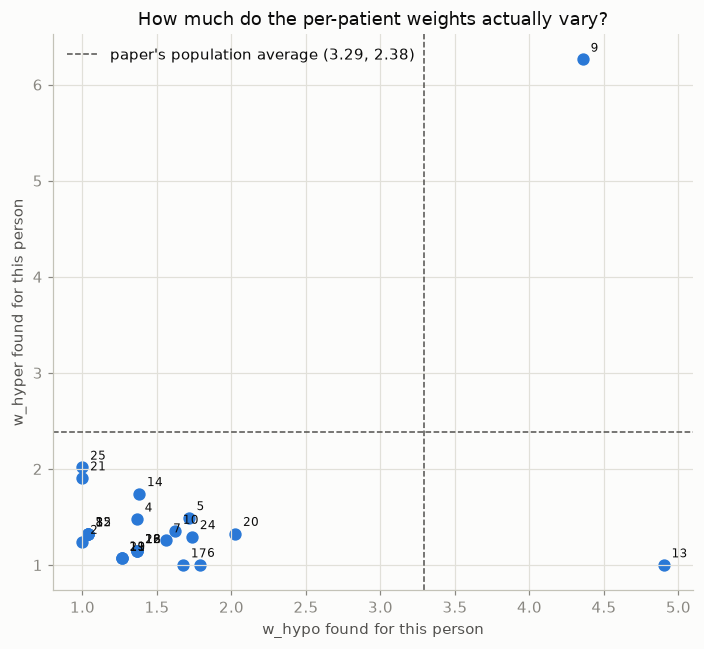

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(weights_table["w_hypo"], weights_table["w_hyper"], color=plotting.CATEGORICAL[0], s=50)
ax.axvline(GLIMMER_WEIGHTS["w_hypo"], color=plotting.INK_SECONDARY, linestyle="--", linewidth=1,
           label=f"paper's population average ({GLIMMER_WEIGHTS['w_hypo']}, {GLIMMER_WEIGHTS['w_hyper']})")
ax.axhline(GLIMMER_WEIGHTS["w_hyper"], color=plotting.INK_SECONDARY, linestyle="--", linewidth=1)
for sid, row in weights_table.iterrows():
    ax.annotate(str(sid), (row["w_hypo"], row["w_hyper"]), fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("w_hypo found for this person")
ax.set_ylabel("w_hyper found for this person")
ax.set_title("How much do the per-patient weights actually vary?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 4. Final models: retrain each patient with their own found weights

The search above used a reduced training budget per candidate, just enough to rank
weight pairs against each other. Now train one real model per patient at the full
budget (same epochs/patience as v0 and v1), using each patient's own weights instead of
the fixed population average. Checkpointed the same way as v0/v1.


In [7]:
V3_CHECKPOINT_DIR = CHECKPOINT_DIR / "cnn_lstm_v3_tuned"

results_v3 = {}
rows = []
for sid, data in prepared_data.items():
    cached = checkpoint.load_result(V3_CHECKPOINT_DIR, sid)
    if cached is not None:
        result = cached
        print(f"Subject {sid}: loaded from checkpoint (RMSE={result.rmse:.2f} mg/dL)")
    else:
        weights = ga_results[sid]["best_weights"]
        result = train_prepared_model(data, architecture="cnn_lstm", epochs=30, region_weights=weights)
        checkpoint.save_result(V3_CHECKPOINT_DIR, result)
        print(f"Subject {sid}: trained and checkpointed (RMSE={result.rmse:.2f} mg/dL)")

    results_v3[sid] = result
    rows.append({"subject_id": sid, "rmse": result.rmse, "mae": result.mae, "n_test": result.n_test})

summary_v3 = pd.DataFrame(rows).set_index("subject_id")
summary_v3.round(2)


Subject 1: trained and checkpointed (RMSE=33.72 mg/dL)


Subject 2: trained and checkpointed (RMSE=39.78 mg/dL)


Subject 3: trained and checkpointed (RMSE=33.18 mg/dL)


Subject 4: trained and checkpointed (RMSE=33.12 mg/dL)


Subject 5: trained and checkpointed (RMSE=33.15 mg/dL)


...

Subject 22: trained and checkpointed (RMSE=40.15 mg/dL)


Subject 23: trained and checkpointed (RMSE=38.49 mg/dL)


Subject 24: trained and checkpointed (RMSE=34.40 mg/dL)


Subject 25: trained and checkpointed (RMSE=44.01 mg/dL)


,rmse,mae,n_test
subject_id,,,
1,33.72,26.73,2169
2,39.78,30.88,2231
3,33.18,25.79,2130
4,33.12,25.16,2543
5,33.15,24.80,2603
6,28.17,20.76,2539
7,37.52,27.55,2670
8,39.36,30.26,1601
9,43.64,34.96,2128


## 5. v0 vs. v1 (fixed weights) vs. v3 (per-patient tuned weights)

The comparison that actually tests whether per-patient tuning fixes what went wrong in
notebook 03. Reuses the same `cnn_lstm_v0`/`cnn_lstm_v1` checkpoints notebook 04 writes
(or writes them fresh here if notebook 04 hasn't run yet), so this doesn't retrain a
third copy of the same two models.


In [8]:
summary_v0, results_v0 = run_with_checkpoints(df, CHECKPOINT_DIR / "cnn_lstm_v0", epochs=30, region_weights=None)
summary_v1, results_v1 = run_with_checkpoints(df, CHECKPOINT_DIR / "cnn_lstm_v1", epochs=30, region_weights=GLIMMER_WEIGHTS)

print(f"v0 (plain loss):          RMSE {summary_v0['rmse'].mean():.2f} +/- {summary_v0['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v0['mae'].mean():.2f} +/- {summary_v0['mae'].std():.2f} mg/dL")
print(f"v1 (fixed avg. weights):  RMSE {summary_v1['rmse'].mean():.2f} +/- {summary_v1['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v1['mae'].mean():.2f} +/- {summary_v1['mae'].std():.2f} mg/dL")
print(f"v3 (per-patient weights): RMSE {summary_v3['rmse'].mean():.2f} +/- {summary_v3['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v3['mae'].mean():.2f} +/- {summary_v3['mae'].std():.2f} mg/dL")
print()
print("Paper's GLIMMER(CNN-LSTM) on AZT1D: RMSE 22.48 +/- 3.57 mg/dL, MAE 15.58 +/- 2.87 mg/dL")


Subject 1: loaded from checkpoint (RMSE=25.29 mg/dL)
Subject 2: loaded from checkpoint (RMSE=36.73 mg/dL)
Subject 3: loaded from checkpoint (RMSE=24.96 mg/dL)
Subject 4: loaded from checkpoint (RMSE=32.12 mg/dL)
Subject 5: loaded from checkpoint (RMSE=26.97 mg/dL)
Subject 6: loaded from checkpoint (RMSE=24.89 mg/dL)
Subject 7: loaded from checkpoint (RMSE=27.97 mg/dL)
Subject 8: loaded from checkpoint (RMSE=35.18 mg/dL)
Subject 9: loaded from checkpoint (RMSE=33.08 mg/dL)
Subject 10: loaded from checkpoint (RMSE=31.25 mg/dL)
Subject 11: loaded from checkpoint (RMSE=33.53 mg/dL)
Subject 12: loaded from checkpoint (RMSE=26.45 mg/dL)
Subject 13: loaded from checkpoint (RMSE=20.97 mg/dL)
Subject 14: loaded from checkpoint (RMSE=32.21 mg/dL)
Subject 15: loaded from checkpoint (RMSE=38.20 mg/dL)
Subject 16: loaded from checkpoint (RMSE=25.57 mg/dL)
Subject 17: loaded from checkpoint (RMSE=44.27 mg/dL)
Subject 18: loaded from checkpoint (RMSE=34.68 mg/dL)
Subject 19: loaded from checkpoint (R

In [9]:
def region_summary(results):
    rows = []
    for sid, r in results.items():
        re = region_errors(r.y_test, r.y_pred)
        for region in ("hypo", "normal", "hyper"):
            rows.append({"subject_id": sid, "region": region, "mae": re[region]["mae"]})
    return pd.DataFrame(rows).groupby("region")["mae"].mean().reindex(["hypo", "normal", "hyper"])

region_compare = pd.DataFrame({
    "v0": region_summary(results_v0),
    "v1": region_summary(results_v1),
    "v3": region_summary(results_v3),
})
region_compare.round(2)


,v0,v1,v3
region,,,
hypo,56.27,53.17,50.29
normal,20.23,32.41,27.92
hyper,40.16,35.90,36.69


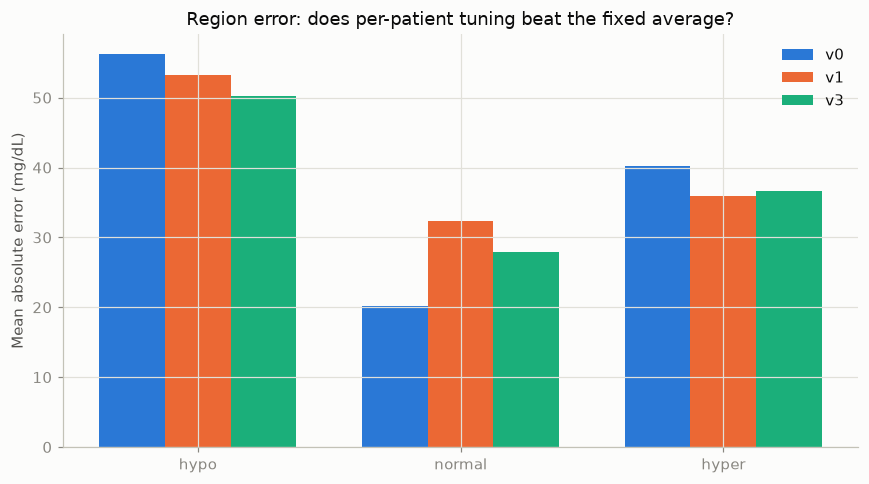

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
regions = ["hypo", "normal", "hyper"]
x = np.arange(3)
width = 0.25
for i, col in enumerate(["v0", "v1", "v3"]):
    ax.bar(x + (i - 1) * width, region_compare.loc[regions, col], width, color=plotting.CATEGORICAL[i], label=col)
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Mean absolute error (mg/dL)")
ax.set_title("Region error: does per-patient tuning beat the fixed average?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 6. Is any of this actually significant?

The paper checks its improvement with a paired Wilcoxon signed-rank test on per-patient
RMSE: same 25 people, before and after, not just an average that could be one or two
outliers doing all the work.


In [11]:
paired = summary_v0[["rmse"]].rename(columns={"rmse": "v0"}).join(
    summary_v1[["rmse"]].rename(columns={"rmse": "v1"})
).join(
    summary_v3[["rmse"]].rename(columns={"rmse": "v3"})
)

for label, a, b in [("v0 vs v1 (fixed weights)", "v0", "v1"), ("v0 vs v3 (tuned weights)", "v0", "v3")]:
    stat, p = wilcoxon(paired[a], paired[b])
    direction = "lower" if paired[b].mean() < paired[a].mean() else "higher"
    print(f"{label}: {b} RMSE is {direction} on average, p-value = {p:.4g} "
          f"({'significant' if p < 0.05 else 'not significant'} at alpha=0.05)")


v0 vs v1 (fixed weights): v1 RMSE is higher on average, p-value = 5.96e-08 (significant at alpha=0.05)
v0 vs v3 (tuned weights): v3 RMSE is higher on average, p-value = 5.96e-08 (significant at alpha=0.05)


## 7. Where this leaves the replication

Once this has actually run, the honest comparison is: does v3's per-patient search
recover the paper's claim that GLIMMER beats the plain baseline overall, not just in the
hypo/hyper regions the way v1 managed? That's the real test of the hypothesis raised in
this notebook's introduction. Worth reading the Section 5 numbers directly rather than
assuming the answer here.

Still not covered, even after this notebook: the paper's own compute budget for the GA
(this one is intentionally smaller), OhioT1DM (not used here), and the Transformer-
specific GLIMMER numbers the excerpt of the paper we have doesn't break out separately
for AZT1D.
